# 01 — Exploratory Data Analysis

**Goal:** profile the H&M Kaggle dataset, identify the wide-leg-denim-equivalent anchor SKUs (the reference category for the case study), and write a clean 30-day sample to `data/interim/sample_30d.parquet` for the downstream notebooks.

**Inputs:** `data/raw/{articles,transactions_train,customers}.csv`
**Outputs:** `data/interim/sample_30d.parquet`, `data/interim/articles_clean.parquet`

**Reference for the case study:** the figures in this notebook anchor the methodology section's framing — *what data we used, how we sampled, what categories anchor the analysis*. See `data/methodology.md`.

**Notebook is scaffold-ready.** Cells run top-to-bottom assuming the Kaggle CSVs are in `../raw/`. If you don't have them yet, see `../README.md` for the download steps.

## 1 · Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAW = Path('../raw')
INTERIM = Path('../interim')
INTERIM.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

# fail loudly if data isn't here
missing = [f for f in ['articles.csv', 'transactions_train.csv'] if not (RAW / f).exists()]
assert not missing, f"Missing files in {RAW}: {missing}. See ../README.md for download steps."

## 2 · Articles catalog

Small file (~37MB), load fully. Key columns for downstream work:
- `article_id` — the SKU primary key
- `product_type_name` — fine-grained product type (e.g., "Trousers", "Sweater")
- `garment_group_name` — coarser group (e.g., "Trousers Denim", "Knitwear")
- `colour_group_name` — colour family for cluster validation
- `index_group_name` — top-level (Ladieswear / Menswear / Children / etc.)

In [2]:
articles = pd.read_csv(RAW / 'articles.csv', dtype={'article_id': str})
print(f"Articles: {len(articles):,} rows, {articles.shape[1]} columns")
articles.head(3)

Articles: 105,542 rows, 25 columns


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,0108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,0108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,0108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.


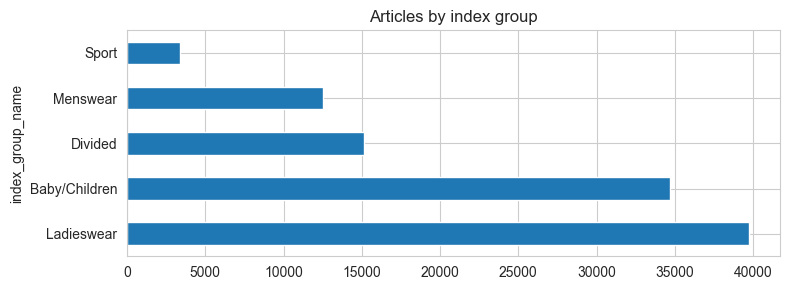

In [3]:
# index_group_name distribution — confirms Ladieswear dominates
articles['index_group_name'].value_counts().plot(kind='barh', figsize=(8, 3))
plt.title('Articles by index group')
plt.tight_layout(); plt.show()

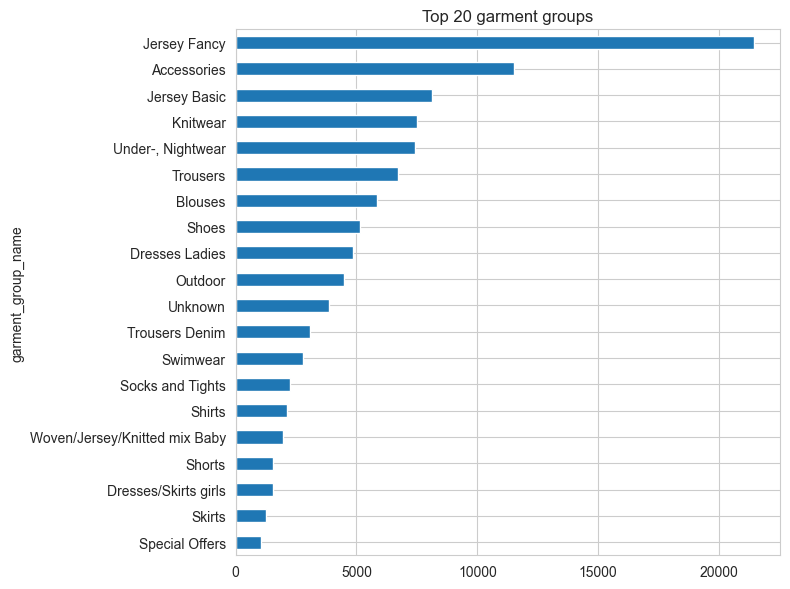

In [4]:
# garment_group_name — the level we'll use for cross-category-coverage checks downstream
articles['garment_group_name'].value_counts().head(20).plot(kind='barh', figsize=(8, 6))
plt.title('Top 20 garment groups')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

### 2.1 · Reference-category anchor: wide-leg denim equivalent

Case study reference category (per CLAUDE.md) is **wide-leg light-blue denim** — a Y2K-revival aesthetic anchor on the Zalando product page. H&M doesn't have a single "wide-leg denim" SKU label, so we approximate with `garment_group_name == 'Trousers Denim'` filtered to a light/medium colour family. This is the anchor for downstream sanity checks — the analysis should produce a community that *includes* these SKUs.

In [5]:
denim = articles[articles['garment_group_name'] == 'Trousers Denim'].copy()
print(f"Denim SKUs: {len(denim):,}")
denim['colour_group_name'].value_counts().head(10)

Denim SKUs: 3,100


colour_group_name
Blue          1041
Light Blue     646
Dark Blue      547
Black          492
Grey            89
Light Grey      68
White           63
Dark Grey       50
Off White       15
Light Pink      13
Name: count, dtype: int64

In [6]:
# Filter to light-blue-ish denim — adjust the colour list once you see the actual distribution above
LIGHT_BLUE_DENIM_COLOURS = ['Light Blue', 'Light Denim Blue', 'Light Dusty Blue']
anchor_skus = denim[denim['colour_group_name'].isin(LIGHT_BLUE_DENIM_COLOURS)]['article_id'].tolist()
print(f"Anchor SKUs (light-blue denim): {len(anchor_skus):,}")
print("Sample:", anchor_skus[:5])

# Save for downstream notebooks
pd.Series(anchor_skus).to_frame('article_id').to_parquet(INTERIM / 'anchor_skus.parquet')

Anchor SKUs (light-blue denim): 646
Sample: ['0305305010', '0348168005', '0398089018', '0398127007', '0399061017']


## 3 · Transactions — date profile and 30-day sample

`transactions_train.csv` is the big one (~3.4GB). Read with explicit dtypes to save memory, then immediately filter to a 30-day window before doing anything else.

**Why 30 days:** documented in `data/methodology.md` — long windows risk seasonal drift; short windows risk sparse co-purchase signal. 30 days is a defensible compromise. Easy to revisit later by changing `WINDOW_DAYS` below.

In [7]:
WINDOW_DAYS = 30

# Streaming read just to find the date range — cheaper than loading the whole file twice.
# Adjust dtypes for memory: article_id is a categorical string in the original
dtypes = {
    'customer_id': 'string',
    'article_id': 'string',
    'price': 'float32',
    'sales_channel_id': 'int8',
}

tx_iter = pd.read_csv(
    RAW / 'transactions_train.csv',
    dtype=dtypes,
    parse_dates=['t_dat'],
    chunksize=2_000_000,
)

# First pass: find max date
max_dat = pd.Timestamp.min
for chunk in tx_iter:
    max_dat = max(max_dat, chunk['t_dat'].max())
print(f"Max transaction date in file: {max_dat.date()}")

cutoff = max_dat - pd.Timedelta(days=WINDOW_DAYS)
print(f"Window: {cutoff.date()} → {max_dat.date()} ({WINDOW_DAYS} days)")

Max transaction date in file: 2020-09-22
Window: 2020-08-23 → 2020-09-22 (30 days)


In [8]:
# Second pass: filter to the window
from tqdm import tqdm

tx_iter = pd.read_csv(
    RAW / 'transactions_train.csv',
    dtype=dtypes,
    parse_dates=['t_dat'],
    chunksize=2_000_000,
)

sample_chunks = []
for chunk in tqdm(tx_iter, desc='filtering'):
    sample_chunks.append(chunk[chunk['t_dat'] >= cutoff])

tx_sample = pd.concat(sample_chunks, ignore_index=True)
print(f"Window sample: {len(tx_sample):,} transactions, {tx_sample['customer_id'].nunique():,} unique customers, {tx_sample['article_id'].nunique():,} unique articles")

filtering: 0it [00:00, ?it/s]

filtering: 1it [00:01,  1.17s/it]

filtering: 2it [00:02,  1.16s/it]

filtering: 3it [00:03,  1.14s/it]

filtering: 4it [00:04,  1.14s/it]

...

filtering: 14it [00:16,  1.15s/it]

filtering: 15it [00:17,  1.15s/it]

filtering: 16it [00:18,  1.12s/it]

filtering: 16it [00:18,  1.14s/it]

Window sample: 1,155,933 transactions, 250,619 unique customers, 29,237 unique articles


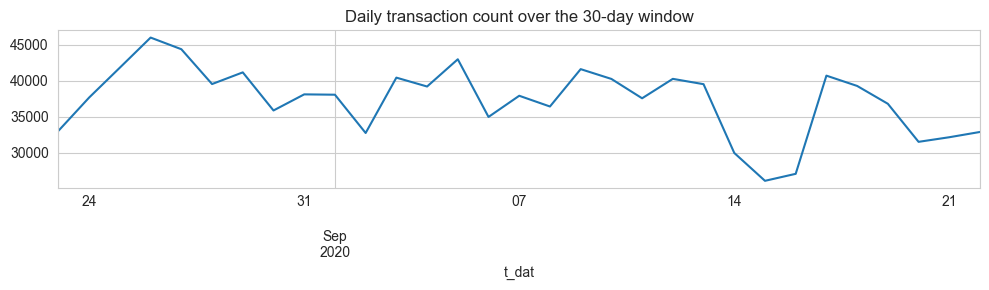

In [9]:
# Daily transaction volume — sanity-check the window
tx_sample.groupby('t_dat').size().plot(figsize=(10, 3))
plt.title(f'Daily transaction count over the {WINDOW_DAYS}-day window')
plt.tight_layout(); plt.show()

In [10]:
# Join in articles metadata once — downstream notebooks need the category fields
tx_sample = tx_sample.merge(
    articles[['article_id', 'product_type_name', 'garment_group_name',
              'colour_group_name', 'index_group_name']],
    on='article_id', how='left'
)

# Sanity: every transaction joined?
missing_meta = tx_sample['product_type_name'].isna().sum()
print(f"Transactions missing article metadata: {missing_meta:,} ({missing_meta / len(tx_sample):.2%})")

Transactions missing article metadata: 0 (0.00%)


## 4 · Basket-shape profile

How many items does the average customer buy per session? This sets expectations for the Apriori step in notebook 02.

**Session definition** (used here AND in notebook 02): a customer's transactions on the same `t_dat` count as one basket. This is approximate — H&M doesn't expose session IDs — but is the standard treatment in the Kaggle competition's published baselines.

In [11]:
basket_sizes = tx_sample.groupby(['customer_id', 't_dat']).size()
print(f"Total baskets: {len(basket_sizes):,}")
print(f"Median basket size: {basket_sizes.median():.0f}")
print(f"Mean basket size: {basket_sizes.mean():.1f}")
print(f"Baskets with 2+ items (usable for co-purchase): {(basket_sizes >= 2).sum():,} ({(basket_sizes >= 2).mean():.1%})")

Total baskets: 368,111
Median basket size: 2
Mean basket size: 3.1
Baskets with 2+ items (usable for co-purchase): 249,226 (67.7%)


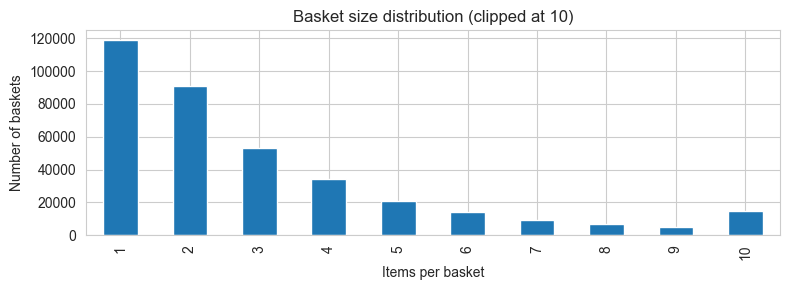

In [12]:
# Visualise — clip at 10 for readability
basket_sizes.clip(upper=10).value_counts().sort_index().plot(kind='bar', figsize=(8, 3))
plt.title('Basket size distribution (clipped at 10)')
plt.xlabel('Items per basket'); plt.ylabel('Number of baskets')
plt.tight_layout(); plt.show()

## 5 · Cross-category coverage in baskets

Per the case study's design principle #3 (alternatives ≠ supplementaries) and competitive-scan anti-pattern #1 (the Baymard 58% finding), Zalando's existing widgets fail by being **same-category monotone**. What does the H&M dataset show — do real baskets cross garment groups?

In [13]:
basket_groups = (
    tx_sample.groupby(['customer_id', 't_dat'])['garment_group_name']
    .nunique()
)
print(f"Multi-item baskets: {(basket_sizes >= 2).sum():,}")
print(f"... of which span 2+ garment groups: {(basket_groups >= 2).sum():,} ({(basket_groups >= 2).sum() / (basket_sizes >= 2).sum():.1%})")
print(f"... of which span 3+ garment groups: {(basket_groups >= 3).sum():,}")
# This number — 'share of multi-item baskets that genuinely cross categories' — anchors the case study's
# claim that style-coherent recommendations should cross garment groups too.

Multi-item baskets: 249,226
... of which span 2+ garment groups: 179,997 (72.2%)
... of which span 3+ garment groups: 82,893


## 6 · Write the sample for downstream notebooks

In [14]:
tx_sample.to_parquet(INTERIM / 'sample_30d.parquet', index=False, compression='snappy')
articles.to_parquet(INTERIM / 'articles_clean.parquet', index=False, compression='snappy')

sz_tx = (INTERIM / 'sample_30d.parquet').stat().st_size / 1024 / 1024
sz_a = (INTERIM / 'articles_clean.parquet').stat().st_size / 1024 / 1024
print(f"Wrote sample_30d.parquet ({sz_tx:.1f} MB)")
print(f"Wrote articles_clean.parquet ({sz_a:.1f} MB)")
print("\nNext: open notebook 02-apriori-basket.ipynb")

Wrote sample_30d.parquet (31.7 MB)
Wrote articles_clean.parquet (6.1 MB)

Next: open notebook 02-apriori-basket.ipynb
